## Multicellular Factor Analysis for spatial data

---

**NOTE**
This is an advanced user notebook. Familiarity with MOFA-based multicellular factor analysis and spatial single-cell analysis is assumed.

---

Patient maps built from single-cell and spatial data can integrate multiple tissue descriptors into a shared latent space. In previous tutorials, we focused mainly on expression-derived multicellular programs. However, spatial data also allows us to describe tissue organization: not only which cell types are present and transcriptionally active, but also how they are arranged relative to each other.

In this tutorial, we extend the mc-ASTRA workflow by adding a spatial view based on `Squidpy`'s **neighborhood enrichment**. For each tissue sample, we quantify whether pairs of cell types are enriched or depleted as spatial neighbors, generating a sample-by-cell-type-pair matrix. This matrix is then incorporated as an additional view in the patient map.

This allows the model to jointly capture:

* multicellular gene expression programs
* spatial organization programs
* tissue differences that may not be visible from expression data alone

---

### Application to Xenium IBD data

We apply this workflow to Xenium spatial transcriptomics data from the intestinal IBD atlas reported in [Pokatayev et al., Nature 2026](https://www.nature.com/articles/s41586-025-09907-x), including Crohn’s disease, ulcerative colitis, and non-IBD intestinal tissue samples.

By integrating neighborhood enrichment and cell compositions as additional views, we ask whether disease-associated tissue differences are reflected not only in transcriptional programs, but also in the local organization of epithelial, immune, stromal, and fibroblast populations.

This tutorial illustrates how mc-ASTRA can incorporate spatial tissue descriptors into patient maps, providing a flexible framework to compare molecular and structural sources of variation across samples. However this tutorial should be useful for users trying to extend their models to multiple other tissue features (e.g. cell compositions).

In [10]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=SyntaxWarning)

import numpy as np
import pandas as pd
import anndata as ad
import decoupler as dc
import matplotlib.pyplot as plt
import seaborn as sns
import math
import scanpy as sc
import mudata as md
import mofaflex as mf
import os
import mc_astra
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

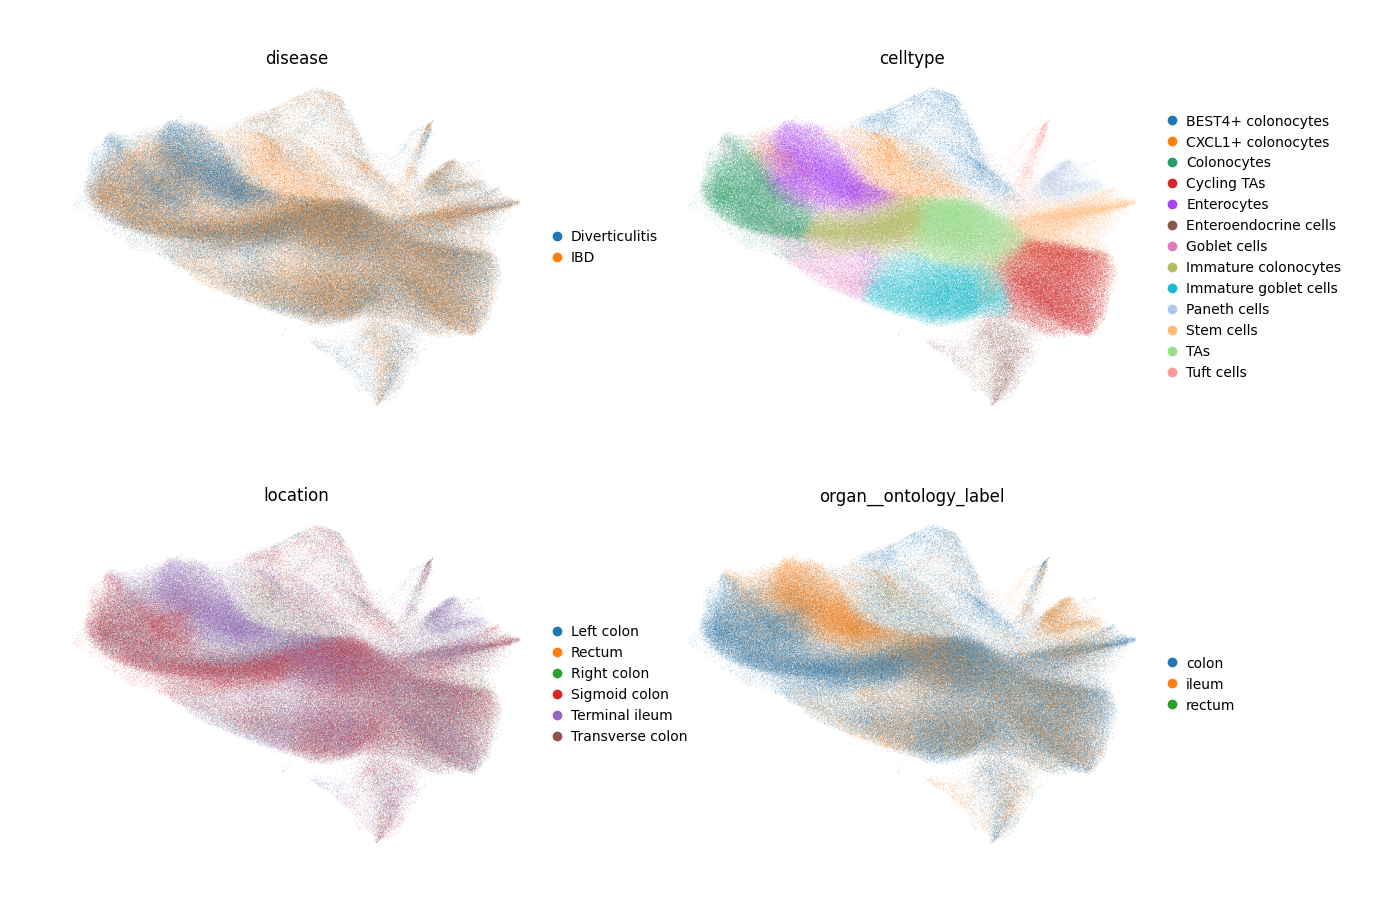

In [11]:
adata = ad.read_h5ad("./data/scp_xenium_human_epi.h5ad")
# If disease category is diverticulitis, then not IBD
adata.obs["disease"] = adata.obs["disease__ontology_label"].apply(lambda x: "IBD" if x in ["ulcerative colitis", "crohn's disease"] else "Diverticulitis")
adata.obs["biosample_id"] = adata.obs["biosample_id"].astype("str")
sc.pl.umap(adata, color=["disease", 'celltype', 'location', 'organ__ontology_label'], frameon=False, ncols=2)

### Processing the AnnData and preparing it for model fitting

Xenium data can be processed identically as single-cell data, thus we can easily used the same functions described in previous tutorials.

In [12]:
# We extract the metadata based on our column that is the reference
# Filter adata to only include ileum
# Process adata_raw
metadata = mc_astra.up.extract_metadata_from_obs(obs=adata.obs, groupby="biosample_id", sort=False)
pdata = dc.pp.pseudobulk(adata, sample_col="biosample_id", groups_col="celltype", layer="counts")

# Manipulations on pdata
pdata.obs = pdata.obs.set_index("biosample_id", drop=False)
pdata.obs.index.name = None

# Make list of adatas per pseudobulk cell type
anndata_dict = mc_astra.up.split_anndata_by_celltype(pdata=pdata, grouping="celltype")

# Adding gene expression total counts - TODO add to upstream as a function
for _cell_type, adata_raw in anndata_dict.items():
    # Sum across observations (rows) for each gene (column)
    if hasattr(adata_raw.X, "toarray"):
        # Sparse matrix case
        total_counts = adata_raw.X.sum(axis=0).A1  # returns 1D array
    else:
        total_counts = adata_raw.X.sum(axis=0)  # numpy array

    # Add to .var
    adata_raw.var["total_counts"] = total_counts


# From all the possible samples, let's ask for at least 40%
n_samples = len(metadata.index)
min_samples = math.trunc(n_samples * 0.4)

# Do filters
mc_astra.up.filter_anndata_by_ncells(anndata_dict, min_cells=20)
mc_astra.up.filter_views_by_samples(anndata_dict, min_rows=min_samples)
mc_astra.up.filter_genes_byexpr(anndata_dict, min_count=20, min_prop=0.4)
mc_astra.up.filter_views_by_genes(anndata_dict, min_genes_per_view=100)
mc_astra.up.filter_samples_by_coverage(anndata_dict, threshold=0, min_prop=0.90)
mc_astra.up.filter_views_by_samples(anndata_dict, min_rows=min_samples)
mc_astra.up.save_raw_counts(anndata_dict, layer_name="raw_counts")
mc_astra.up.norm_log(anndata_dict, target_sum=1e6, exclude_highly_expressed=False, max_value=None, center=True)
mc_astra.up.filter_hvgs(anndata_dict, groupby = None, ngroups_cut = None)
mc_astra.up.filter_smpls_by_nview(anndata_dict, min_views = 5)
mc_astra.up.utils.append_view_to_var(anndata_dict)

Raw counts saved in the 'raw_counts' layer for each AnnData object.
Normalization, log-transformation, and scaling complete for all AnnData objects with target_sum = 1000000.0.


### Fit the multicellular factor model

We first we will fit a model on expression data only to find if we are able to distinguish differences between IBD and non-IBD samples from expression alone. The model is fitted identically as in previous tutorials

WARNING	Device cuda is not available. Using default device: cpu


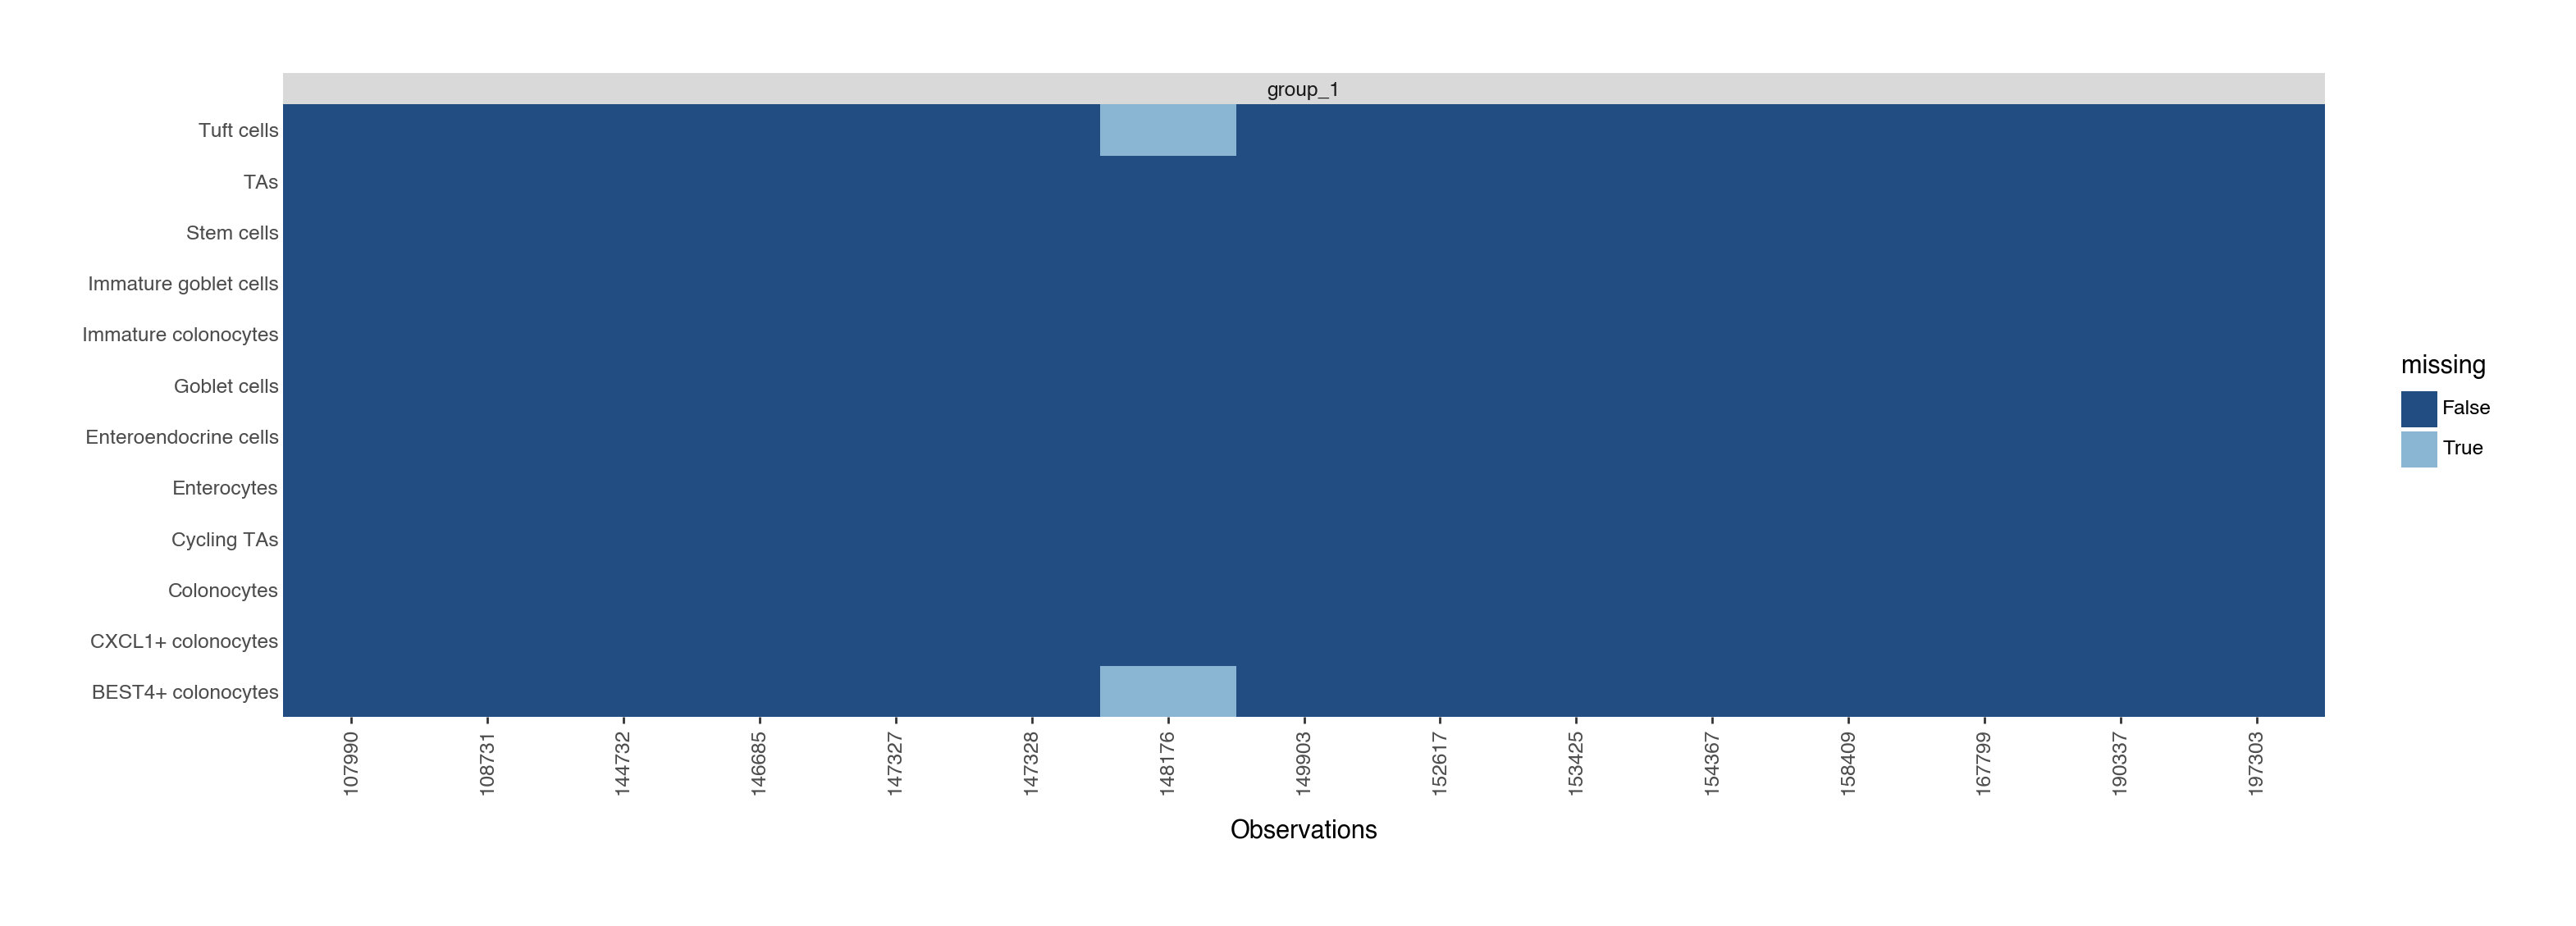

INFO	Initializing factors using 'pca' method...
 79%|███████▉  | 7938/10000 [06:05<01:34, 21.74epoch/s, Loss=1.5e+3]


In [13]:
mdata = md.MuData(anndata_dict)
# Fitting model
model = mf.terms.MofaFlex(n_factors=3, weight_prior="Horseshoe", init_factors="pca")
model.fit(mdata, seed=42, save_path=False, lr=0.001, early_stopper_patience=1000, likelihoods="Normal", update_every = False)


Testing for association with disease labels

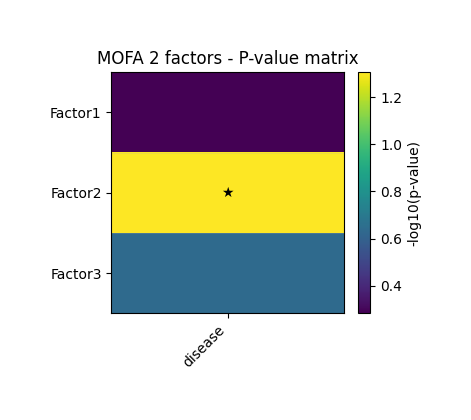

In [14]:
amodel = mc_astra.down.model_to_anndata(
    anndata_dict=anndata_dict,
    metadata=metadata,
    model=model,
)

# Get the p-value matrix for the associations of interest (adjusted)
all_assocs = mc_astra.down.get_pval_matrix(amodel,["disease"])
mc_astra.pl.pl.plot_pval_tiles(all_assocs, title="MOFA 2 factors - P-value matrix",star_threshold=0.1)
plt.show()

In [15]:
mc_astra.down.get_associations(amodel, 
                           test_variable = "disease",
                           test_type="categorical",
                           random_effect = None)

,feature,statistic,p_value,adj_p_value
0,Factor1,0.434978,0.521069,0.521069
1,Factor2,7.570675,0.016491,0.049473
2,Factor3,2.297482,0.153516,0.230275


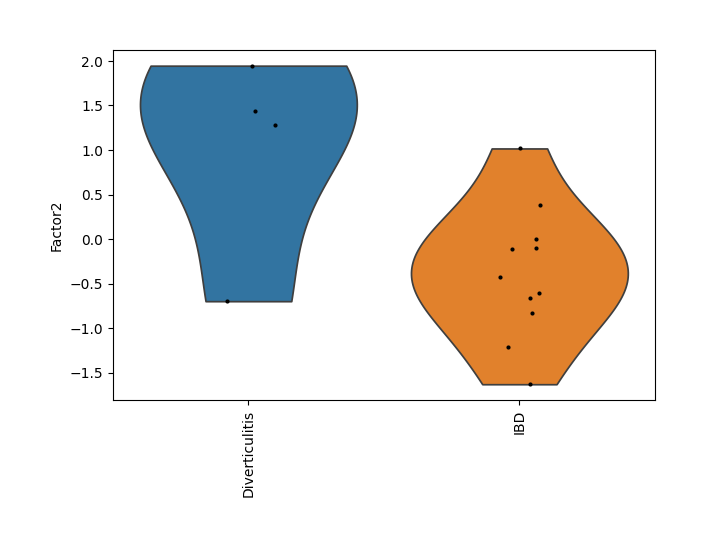

In [16]:
sc.pl.violin(amodel, 
             "Factor2", 
             groupby="disease", 
             rotation=90,
             size = 3,
             dodge=False)

### Adding spatial information

In this setup, gene expression data already recovers differences between diseases, but what if we could add a new covariate that incorporates other relevant features, such as spatial structure. `squidpy` offers multiple spatial metrics, but for simplicity we have wrapped their spatial enrichment metrics, so that for a given multi-sample dataset one can generate a view with spatial information.

Given the use of lists of anndatas, adding any other tissue descriptor is intuitive and easy to do.

In [17]:
spatial_interaction_adata = mc_astra.up.get_nhood_enrichment_feats(
    adata,
    sample_key="biosample_id",
    cluster_key="celltype",
    diagonal = True, # To not be biased by compositions
    n_perms=1000,
    metadata=metadata
)

# Don't forget to add the view name to the variables for compatibility
mc_astra.up.utils.append_view_to_var({"Spatial":spatial_interaction_adata})

anndata_dict["Spatial"] = spatial_interaction_adata

INFO     Creating graph using `None` transform and `1` libraries.                                                  


  0%|          | 0/1000 [00:00<?, ?/s]/Users/flores/Dropbox/EBI/Research/mc_astra_docs/.venv/lib/python3.12/site-packages/scanpy/_utils/__init__.py:33: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  from anndata import __version__ as anndata_version
/Users/flores/Dropbox/EBI/Research/mc_astra_docs/.venv/lib/python3.12/site-packages/scanpy/__init__.py:24: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):
/Users/flores/Dropbox/EBI/Research/mc_astra_docs/.venv/lib/python3.12/site-packages/scanpy/readwrite.py:16: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):
100%|██████████| 1000/1000 [00:04<00:00, 206.35/s]


INFO     Creating graph using `None` transform and `1` libraries.                                                  


  0%|          | 0/1000 [00:00<?, ?/s]/Users/flores/Dropbox/EBI/Research/mc_astra_docs/.venv/lib/python3.12/site-packages/scanpy/_utils/__init__.py:33: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  from anndata import __version__ as anndata_version
/Users/flores/Dropbox/EBI/Research/mc_astra_docs/.venv/lib/python3.12/site-packages/scanpy/__init__.py:24: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):
/Users/flores/Dropbox/EBI/Research/mc_astra_docs/.venv/lib/python3.12/site-packages/scanpy/readwrite.py:16: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):
100%|██████████| 1000/1000 [00:03<00:00, 269.95/s]


INFO     Creating graph using `None` transform and `1` libraries.                                                  


...

  0%|          | 0/1000 [00:00<?, ?/s]/Users/flores/Dropbox/EBI/Research/mc_astra_docs/.venv/lib/python3.12/site-packages/scanpy/_utils/__init__.py:33: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  from anndata import __version__ as anndata_version
/Users/flores/Dropbox/EBI/Research/mc_astra_docs/.venv/lib/python3.12/site-packages/scanpy/__init__.py:24: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):
/Users/flores/Dropbox/EBI/Research/mc_astra_docs/.venv/lib/python3.12/site-packages/scanpy/readwrite.py:16: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):
100%|██████████| 1000/1000 [00:04<00:00, 241.78/s]


INFO     Creating graph using `None` transform and `1` libraries.                                                  


  0%|          | 0/1000 [00:00<?, ?/s]/Users/flores/Dropbox/EBI/Research/mc_astra_docs/.venv/lib/python3.12/site-packages/scanpy/_utils/__init__.py:33: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  from anndata import __version__ as anndata_version
/Users/flores/Dropbox/EBI/Research/mc_astra_docs/.venv/lib/python3.12/site-packages/scanpy/__init__.py:24: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):
/Users/flores/Dropbox/EBI/Research/mc_astra_docs/.venv/lib/python3.12/site-packages/scanpy/readwrite.py:16: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):
100%|██████████| 1000/1000 [00:03<00:00, 331.29/s]


INFO     Creating graph using `None` transform and `1` libraries.                                                  


  0%|          | 0/1000 [00:00<?, ?/s]/Users/flores/Dropbox/EBI/Research/mc_astra_docs/.venv/lib/python3.12/site-packages/scanpy/_utils/__init__.py:33: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  from anndata import __version__ as anndata_version
/Users/flores/Dropbox/EBI/Research/mc_astra_docs/.venv/lib/python3.12/site-packages/scanpy/__init__.py:24: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):
/Users/flores/Dropbox/EBI/Research/mc_astra_docs/.venv/lib/python3.12/site-packages/scanpy/readwrite.py:16: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):
100%|██████████| 1000/1000 [00:04<00:00, 203.53/s]


### Fit the multicellular factor model

Now we just need to re-run the model with this additional view. Nothing changes

WARNING	Device cuda is not available. Using default device: cpu


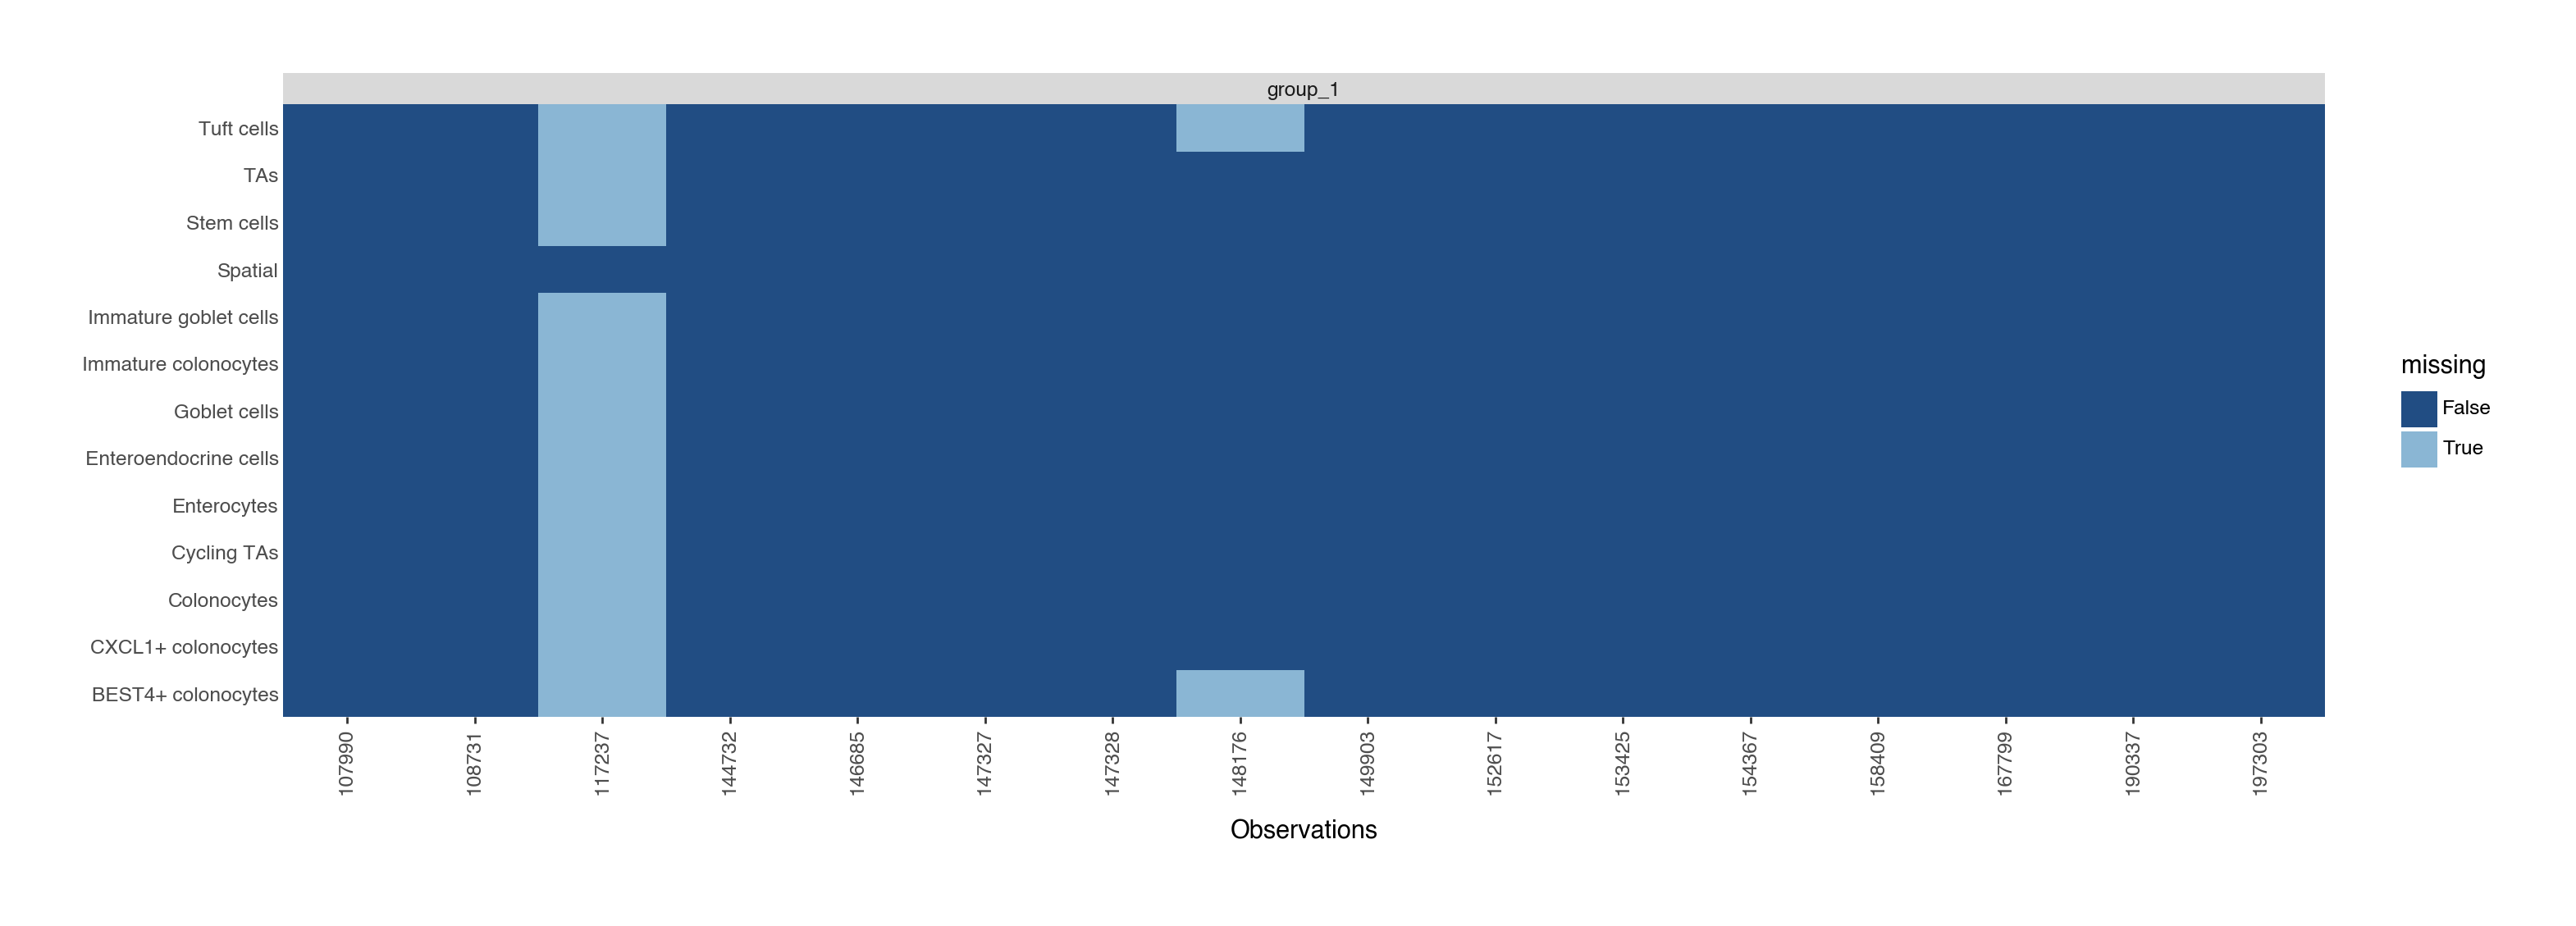

INFO	Initializing factors using 'pca' method...
 96%|█████████▌| 9585/10000 [08:33<00:22, 18.68epoch/s, Loss=1.85e+3]


In [18]:
mdata = md.MuData(anndata_dict)
# Fitting model
model_spatial = mf.terms.MofaFlex(n_factors=3, weight_prior="Horseshoe", init_factors="pca")
model_spatial.fit(mdata, seed=42, save_path=False, lr=0.001, early_stopper_patience=1000, likelihoods="Normal")

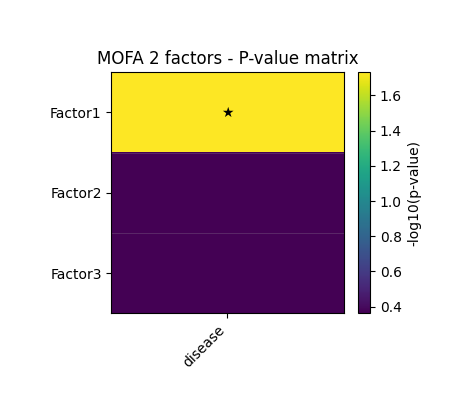

In [19]:
amodel = mc_astra.down.model_to_anndata(
    anndata_dict=anndata_dict,
    metadata=metadata,
    model=model_spatial,
)

# Get the p-value matrix for the associations of interest (adjusted)
all_assocs = mc_astra.down.get_pval_matrix(amodel,["disease"])
mc_astra.pl.pl.plot_pval_tiles(all_assocs, title="MOFA 2 factors - P-value matrix",star_threshold=0.1)
plt.show()

In [20]:
mc_astra.down.get_associations(amodel, 
                           test_variable = "disease",
                           test_type="categorical",
                           random_effect = None)

,feature,statistic,p_value,adj_p_value
0,Factor1,10.357606,0.006191,0.018572
1,Factor2,0.924408,0.352633,0.433877
2,Factor3,0.649186,0.433877,0.433877


Adding the spatial information impacted positively the description of patients since we observed a larger size effect in the difference

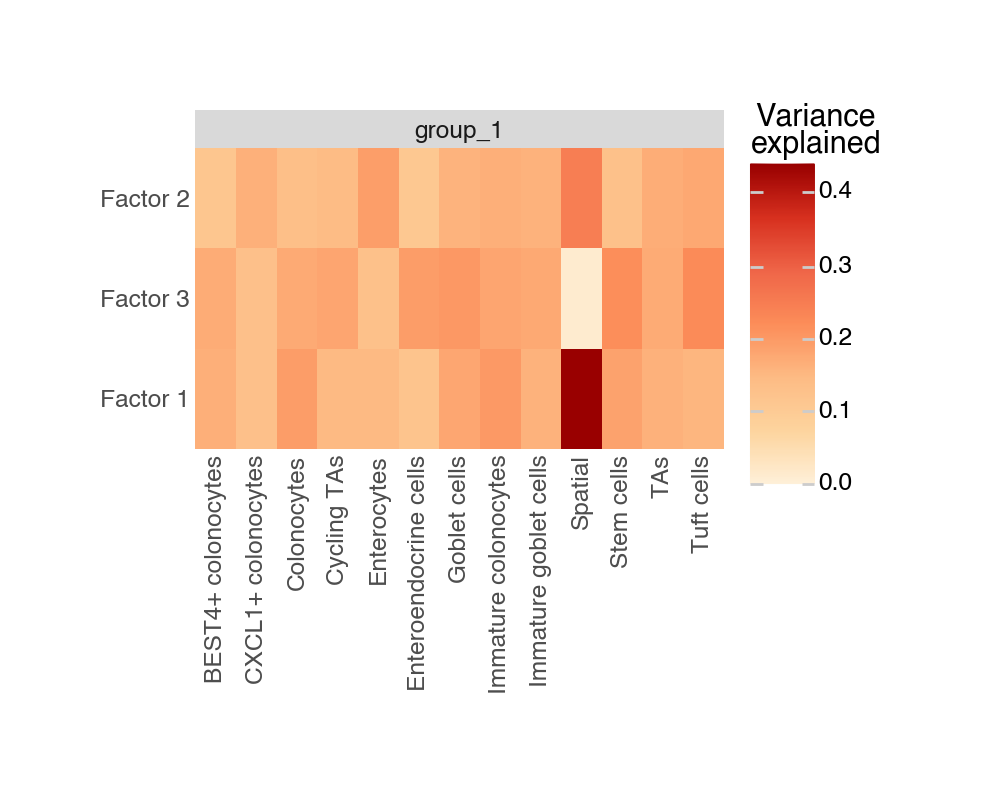

In [21]:
mf.pl.variance_explained(model_spatial, figsize=(4,3))

A clearer quantification is looking at the explained variance. We observe that Factor 1, explains a large portion of variance of the spatial view. At the same time, this result supports the evident relationship between spatial organization and multicellular gene expression coordination.

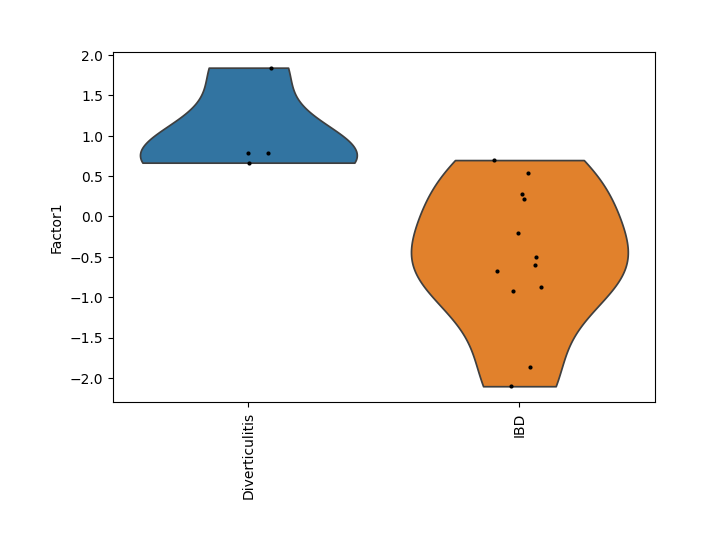

In [22]:
sc.pl.violin(amodel, 
             "Factor1", 
             groupby="disease", 
             rotation=90,
             size = 3,
             dodge=False)

### Characterization of the factor capturing spatial and molecular remodeling

In [23]:
feature_loadings = pd.DataFrame(amodel.varm["gene_loadings"], columns=amodel.uns['gene_loadings_columns'])
feature_loadings.index = amodel.var.index.to_list()
# Make a dictionary of gene expression loadings and spatial loadings
feature_loadings = mc_astra.down.split_by_view(feature_loadings)
spatial_loadings = {"Spatial":feature_loadings["Spatial"]}
feature_loadings = {k:v for k,v in feature_loadings.items() if k != "Spatial"}

In [24]:
# Pick top 10 most negative and positive loadings for the spatial view
F1_loadings = spatial_loadings["Spatial"].loc["Factor1",:]
F1_loadings = F1_loadings.sort_values()
top_pos = F1_loadings.tail(16)
top_neg = F1_loadings.head(16)
top_loadings = pd.concat([top_pos, top_neg])

When looking at the top 32 features characterizing the samples, we see that an increased spatial co-localization of cyclingTAs and Enterocytes 

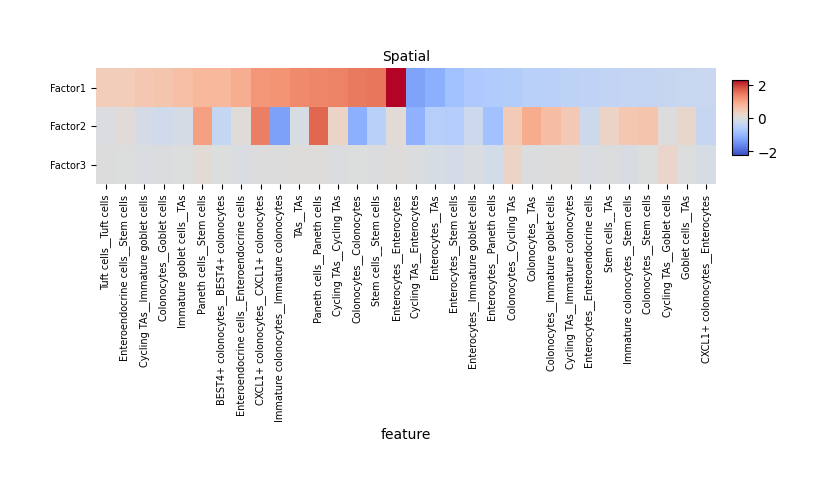

In [25]:
mc_astra.pl.plot_features_per_view(df_dict=spatial_loadings, 
                               features=top_loadings.index.tolist(), 
                               figsize=(8, 1.5))

We can then question if multicellular molecular coordination increases with spatial proximity. First we calculate a multicellular information network. 

In [26]:
MINs = mc_astra.down.get_multicell_net(
    test_model = amodel,
    sel_factor = "Factor1",
    random_effect = None,
    standardize = True,
    drop_na = True,
    verbose = True,
    views=[k for k in feature_loadings.keys()],
    percentile=0.6
)

Then we will contrast the coordination values between the IBD and non-IBD coordination network

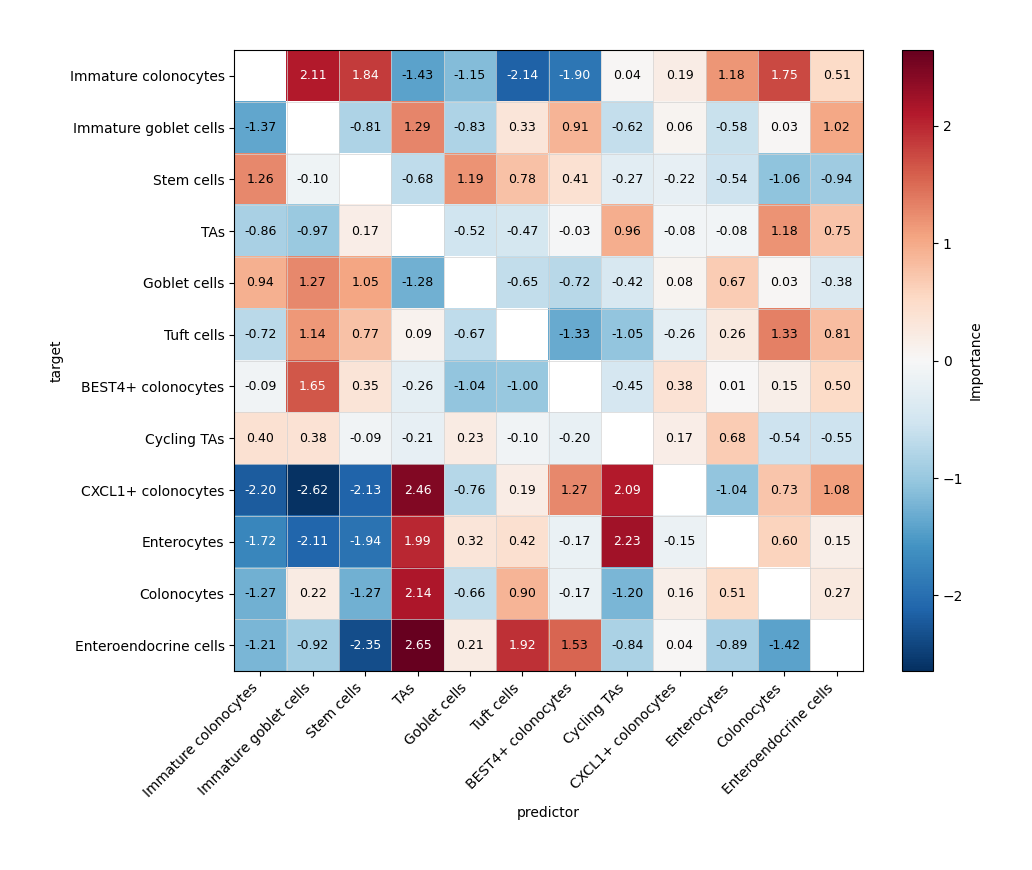

In [27]:
# Make the change between the two dataframes and plot the difference
MINs["change"] = MINs["negative"].copy()
# Ensure that the target and predictor columns are the same in both dataframes
MINs["change"] = MINs["change"].merge(MINs["positive"], on=["target", "predictor"], suffixes=("_neg", "_pos"))
MINs["change"]["cor_estimate"] = MINs["change"]["cor_estimate_neg"] - MINs["change"]["cor_estimate_pos"]

mc_astra.pl.plot_interaction_tileplot(df=MINs["change"], value_col="cor_estimate", row_col="target", col_col="predictor", 
                          cluster_by = "columns", same_order_for_rows_cols=True, 
                          fill_missing_for_clustering=0.0, 
                          cmap="RdBu_r", center=0.0, vlim=None, 
                          show_values=True, value_decimals=2, 
                          figsize=(10, 8), cbar_label="Importance", linewidth=0.5, linecolor="lightgrey", text_kwargs=None)

Focusing on Enterocytes, we observed that within IBD samples, Cycling TAs became a better predictor of their molecular states, which is in line with the top spatial rearrangement. Suggesting that cellular proximity makes these two cell-types more prone to cooperate. This shows how multicellular coordination and spatial organization can be combined within mc-ASTRA to better understand tissue remodeling processes

## Summary

This notebook shows how mc-ASTRA can be used to build multimodal patient maps that incorporate molecular and structural characteristics in the tissue. 

As emerging single-cell technologies with spatial resolution start profiling larger sample cohorts, these type of exploratory analyses are useful to delineate the specific tissue descriptors whose change define a remodeling process. While mc-ASTRA provides a native use of squidpy's enrichment analysis. Similar analyses can be done with alternative tools such as the global descriptors of [MISTy](https://link.springer.com/article/10.1186/s13059-022-02663-5) or the local descriptors available in [LIANA+](https://www.nature.com/articles/s41556-024-01469-w)